## Import Required Libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load & Import the Dataset

In [52]:
df = pd.read_csv("california_sold_properties_2026_final.csv")
df.head()
df.info
print(df.isnull().sum())

type                             0
sub_type                      7933
listPrice                      188
sqft                           673
stories                       1214
beds                           622
baths                          576
baths_full                     703
baths_full_calc                651
garage                        2803
year_built                     618
sanitized_property_summary       0
dtype: int64


## Handle Missing Values

In [53]:
df = df.dropna()
print (df.isnull().sum())
df.describe()

type                          0
sub_type                      0
listPrice                     0
sqft                          0
stories                       0
beds                          0
baths                         0
baths_full                    0
baths_full_calc               0
garage                        0
year_built                    0
sanitized_property_summary    0
dtype: int64


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
count,1.198000e+03,1198.000000,1198.000000,1198.000000,1198.000000,1198.000000,1198.000000,1198.000000,1198.000000
mean,8.671480e+05,1414.282137,1.795492,2.435726,2.426544,1.980801,2.024207,1.688648,1991.432387
std,5.885185e+05,476.343219,0.758629,0.798155,0.791051,0.634933,0.613342,0.544484,19.169255
min,1.699000e+05,422.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1890.000000
25%,5.390250e+05,1070.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1979.000000
50%,6.900000e+05,1350.500000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1987.000000
75%,9.980000e+05,1694.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2006.000000
max,7.500000e+06,3454.000000,5.000000,5.000000,6.000000,5.000000,5.000000,3.000000,2026.000000


## Convert listprice into integers

In [54]:
# Remove decimals
df['listPrice'] = df['listPrice'].astype(int)

# Create a formatted column with commas for display
df['listPrice_formatted']= df['listPrice'].apply(lambda x: "{:,}".format(x))

df.head()
print (df.dtypes)

type                              str
sub_type                          str
listPrice                       int64
sqft                          float64
stories                       float64
beds                          float64
baths                         float64
baths_full                    float64
baths_full_calc               float64
garage                        float64
year_built                    float64
sanitized_property_summary        str
listPrice_formatted               str
dtype: object


## Convert float Values into integers

In [55]:
# List of float columns to convert
float_cols = ['sqft', 'stories', 'baths', 'beds', 'baths_full_calc', 'garage', 'year_built']

# Convert to integers
df[float_cols] = df[float_cols].astype(int)

# Check Result
print(df[float_cols].dtypes)

sqft               int64
stories            int64
baths              int64
beds               int64
baths_full_calc    int64
garage             int64
year_built         int64
dtype: object


## Shorten Property Summary Column to first 50 characters

In [56]:
df['sanitized_property_summary'] = df['sanitized_property_summary'].str[:50] +'...'
df.head()

,type,sub_type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,sanitized_property_summary,listPrice_formatted
47,condos,condo,980000,1900,1,3,3,2.0,2,2,2009,"Tucked into a prime pocket, this stylish 2009-...","980,000"
48,townhomes,townhouse,899000,1700,2,3,2,2.0,2,2,1976,features 3 bedrooms and 2 bathrooms. Light-fil...,"899,000"
52,townhomes,townhouse,850000,1303,3,2,3,2.0,2,2,2016,"With 2 bedrooms and 2.5 baths, the layout feel...","850,000"
57,townhomes,townhouse,635000,1290,3,2,3,2.0,2,2,2023,"2-bedroom, 2.5-bath residence offers the perfe...","635,000"
65,condos,condo,1028000,1425,1,2,2,2.0,2,2,1973,"2-bedroom, 2-bath condominium offers over 1, 4...","1,028,000"


## Advanced Visualizations

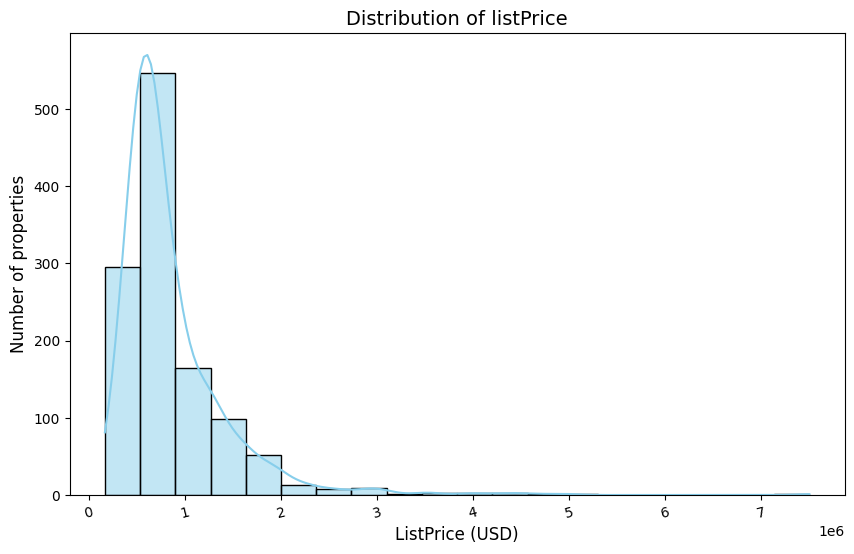

In [57]:
plt.figure(figsize=(10,6))
sns.histplot(df['listPrice'],bins= 20, kde= True, color='skyblue')
plt.title('Distribution of listPrice', fontsize= 14)
plt.xlabel( 'ListPrice (USD)', fontsize=12)
plt.ylabel( 'Number of properties', fontsize= 12)
plt.xticks(rotation= 14)
plt.show()

## Spotting trends between Price with Sqft

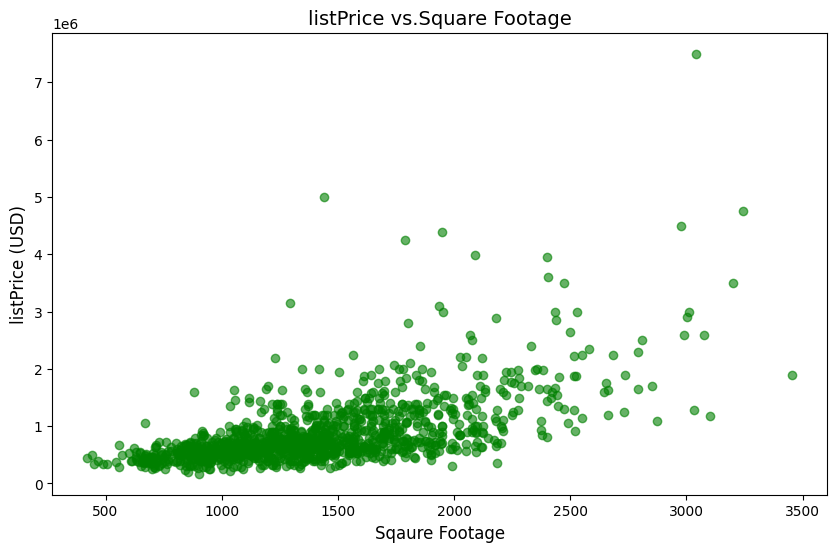

In [58]:
plt.figure(figsize=(10,6))
plt.scatter(df['sqft'], df['listPrice'],color='green',alpha= 0.6)
plt.title('listPrice vs.Square Footage', fontsize=14)
plt.xlabel('Sqaure Footage', fontsize=12)
plt.ylabel('listPrice (USD)', fontsize=12)
plt.show()

## Stories, Beds, Baths Chart

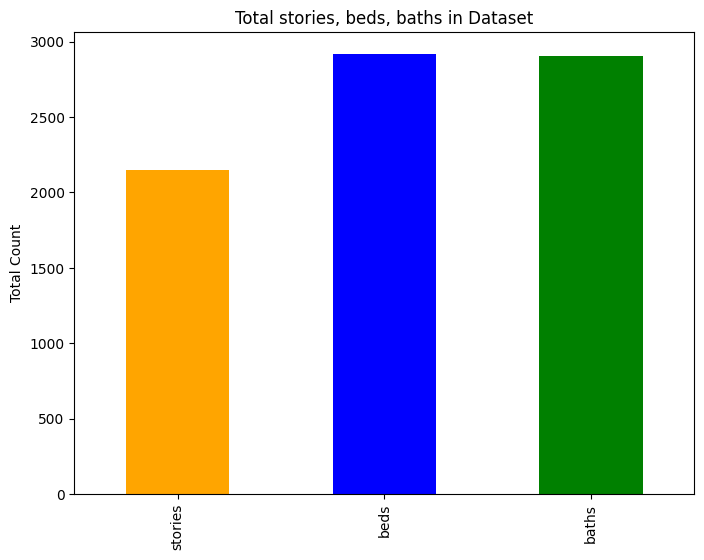

In [66]:

totals= df[['stories', 'beds', 'baths']].sum().plot.bar(
    figsize=(8,6),
    color= ['orange', 'blue', 'green'],
    title= 'Total stories, beds, baths in Dataset',
    ylabel= 'Total Count'
)
plt.show()